# Day17 Assignment :Build Your Own Intelligent Image Search Engine

Divyashree R

## Objective
The objective of this project is to build an intelligent image search engine that retrieves relevant images based on natural language queries.


## Workflow Overview
1. Upload image dataset
2. Generate metadata for each image using Gemini
3. Store metadata as JSON files
4. Convert metadata into LangChain documents
5. Generate embeddings for semantic search
6. Store embeddings in Chroma vector database
7. Retrieve relevant images based on user query
8. Display the results


In [1]:
import os
import base64
import json
import mimetypes
from PIL import Image
from tqdm import tqdm

In [18]:
import google.generativeai as genai
from google.colab import userdata

api_key = userdata.get("GEMINI_API_KEY")

genai.configure(api_key=api_key)

model = genai.GenerativeModel("gemini-3.1-flash-lite-preview")

In [3]:
os.makedirs("dataset_images", exist_ok=True)
os.makedirs("metadata", exist_ok=True)

In [4]:
import shutil
import os

if os.path.exists("dataset_images"):
    shutil.rmtree("dataset_images")

os.makedirs("dataset_images")

In [5]:
from google.colab import files
import os

os.makedirs("my-dataset", exist_ok=True)

uploaded = files.upload()

for filename in uploaded.keys():
    with open(os.path.join("my-dataset", filename), "wb") as f:
        f.write(uploaded[filename])

print("Uploaded files:", os.listdir("my-dataset"))

Saving car.jfif to car.jfif
Saving car_toy.jfif to car_toy.jfif
Saving cowcalf.jfif to cowcalf.jfif
Saving deer_image.jfif to deer_image.jfif
Saving girl_elph.jfif to girl_elph.jfif
Saving teddy_img.jfif to teddy_img.jfif
Saving toys_images.jfif to toys_images.jfif
Uploaded files: ['car_toy.jfif', 'cowcalf.jfif', 'girl_elph.jfif', 'toys_images.jfif', 'car.jfif', 'deer_image.jfif', 'teddy_img.jfif']


In [13]:
image_prompt = """
You are an expert computer vision metadata specialist.

Analyze the image and extract the following information.

Return output in JSON format with:

description: short description of image
objects: list of objects present
setting: environment (indoor/outdoor)
colors: dominant colors
keywords: important search keywords
"""

In [7]:
def encode_image(image_path):

    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

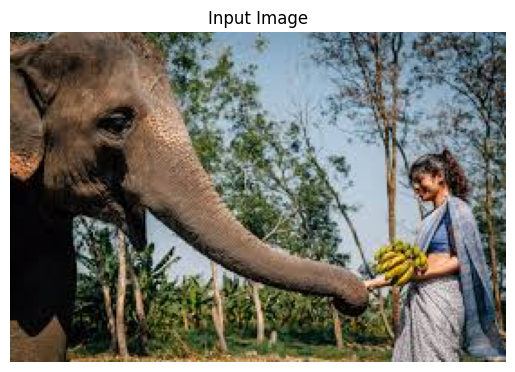

In [44]:
from PIL import Image
import matplotlib.pyplot as plt

image_path = "dataset_images/girl_elph.jfif"

image = Image.open(image_path)

plt.imshow(image)
plt.axis("off")
plt.title("Input Image")
plt.show()

In [19]:
image_path = "dataset_images/girl_elph.jfif"

image = Image.open(image_path)

response = model.generate_content(
    [
        image_prompt,
        image
    ]
)

print(response.text)

```json
{
  "description": "A young woman wearing a traditional saree feeding a bunch of bananas to a large Asian elephant in a rural, outdoor setting.",
  "objects": [
    "elephant",
    "woman",
    "bananas",
    "trees",
    "saree"
  ],
  "setting": "outdoor",
  "colors": [
    "grey",
    "green",
    "blue",
    "yellow",
    "brown"
  ],
  "keywords": [
    "elephant",
    "feeding",
    "wildlife",
    "nature",
    "saree",
    "interaction",
    "asia",
    "conservation",
    "animal husbandry",
    "human-animal bond"
  ]
}
```


In [20]:
import time

image_folder = "dataset_images"

for img_name in tqdm(sorted(os.listdir(image_folder))):

    path = os.path.join(image_folder, img_name)

    image = Image.open(path)

    response = model.generate_content(
        [
            image_prompt,
            image
        ]
    )

    text = response.text.replace("```json","").replace("```","")
    metadata = json.loads(text)

    with open(f"metadata/{img_name}.json", "w") as f:
        json.dump(metadata, f, indent=4)

    time.sleep(15)   # sleep AFTER request

100%|██████████| 7/7 [02:08<00:00, 18.42s/it]


In [22]:
!pip install -q langchain langchain-google-genai langchain-chroma chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.6/21.6 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.0/142.0 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.7/68.7 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 5.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently 

In [23]:
from langchain_google_genai import GoogleGenerativeAIEmbeddings
from langchain_chroma import Chroma
from langchain_core.documents import Document

In [24]:
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    google_api_key=api_key
)

In [25]:
import os
documents = []

metadata_folder = "metadata"

for file in os.listdir(metadata_folder):

    path = os.path.join(metadata_folder, file)

    with open(path) as f:
        data = json.load(f)

    text = json.dumps(data)

    documents.append(
        Document(
            page_content=text,
            metadata={"image": file.replace(".json","")}
        )
    )

print("Loaded documents:", len(documents))

Loaded documents: 7


In [26]:
vectordb = Chroma.from_documents(
    documents,
    embedding=embeddings,
    persist_directory="image_vector_db"
)

In [36]:
retriever = vectordb.as_retriever(
    search_kwargs={"k":2}
)

In [37]:
def search_images(query):

    results = retriever.invoke(query)

    images = []

    for r in results:
        images.append(r.metadata["image"])

    return images

In [38]:
results = search_images("animal")

print(results)

['cowcalf.jfif', 'girl_elph.jfif']


In [39]:
import matplotlib.pyplot as plt

def show_results(results):

    for img in results:

        path = f"dataset_images/{img}"

        image = Image.open(path)

        plt.imshow(image)
        plt.axis("off")
        plt.show()

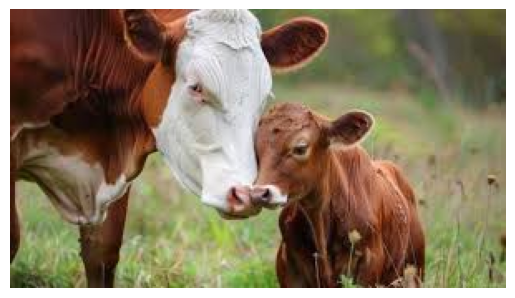

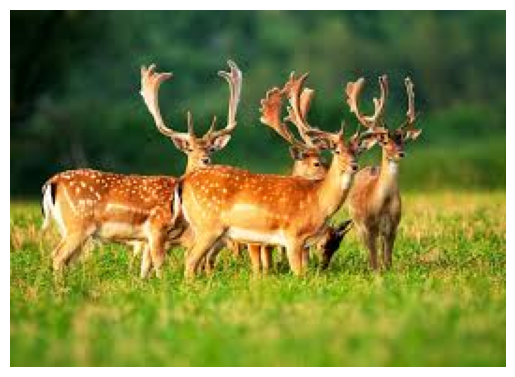

In [46]:
query = "animals"

results = search_images(query)

show_results(results)

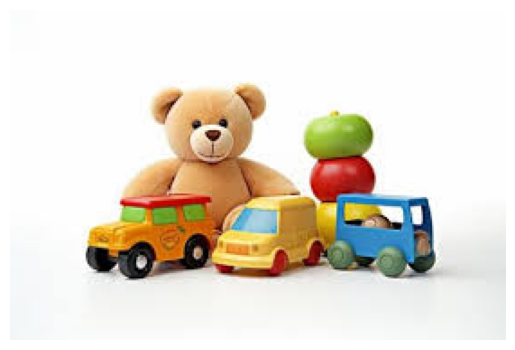

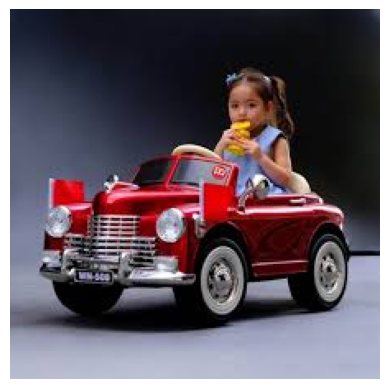

In [43]:
query = "toy"

results = search_images(query)

show_results(results)

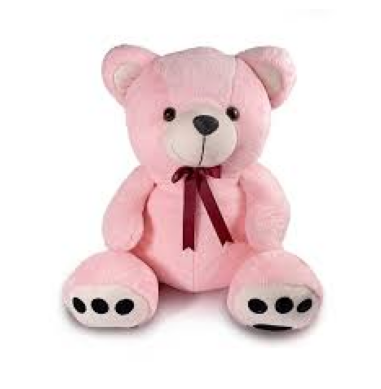

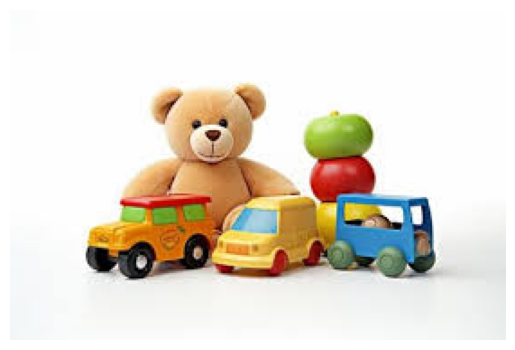

In [45]:
query = "teddy bear"

results = search_images(query)

show_results(results)